In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv('D:/DEPI/Amit/Amit/machine_learning/In-Sessions/data_sets/Social_Network_Ads.csv')
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
x = data.iloc[:,[2,3]]
y = data.iloc[:,4]


In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=20)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test  = sc_x.transform(x_test)


In [9]:
from sklearn.linear_model import LogisticRegression
classifier  =  LogisticRegression()
classifier.fit(x_train,y_train)
y_pred= classifier.predict(x_test)


In [10]:
from sklearn.metrics import confusion_matrix ,accuracy_score,precision_score,recall_score,f1_score


In [12]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[43,  2],
       [ 9, 26]])

In [15]:
tp,fp,fn,tn = cm.ravel()

In [17]:
tp

np.int64(43)

In [ ]:
def accuracy_sc(tp,fp,fn,tn):
   return (tp + tn)/(tp+fp+fn+tn)


In [19]:
accuracy_sc(tp,fp,fn,tn)

np.float64(0.8625)

In [20]:
acc = accuracy_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
f1_sc = f1_score(y_test,y_pred)

In [22]:
print("accuracy_score = ",acc)
print("recall_score = ",recall)
print("precision_score = ",precision)
print("f1_score = ",f1_sc)

accuracy_score =  0.8625
recall_score =  0.7428571428571429
precision_score =  0.9285714285714286
f1_score =  0.8253968253968254


C:\Users\hp\AppData\Local\Temp\ipykernel_24888\2063730673.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j,1],


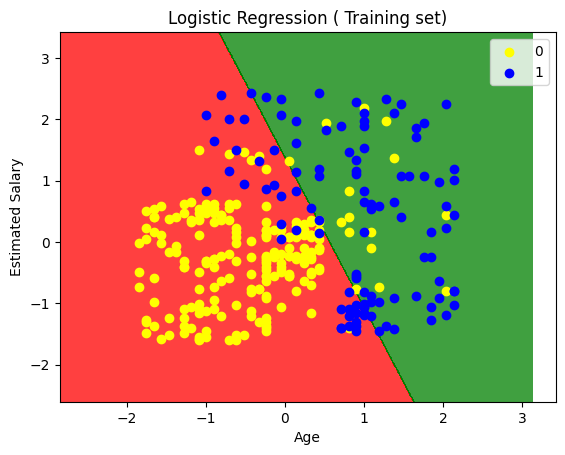

In [23]:

# Visualising the Training set results
 
from matplotlib.colors import ListedColormap
X_Set, Y_Set = x_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_Set[:,0].min() -1, stop = X_Set[:, 0].max() +1, step = 0.01),
                     np.arange(start = X_Set[:,1].min() -1, stop = X_Set[:, 1].max() +1, step = 0.01))
 
 
plt.contourf(X1,X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
 
plt.xlim(X1.min(), X2.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_Set)):
    plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j,1],
                c = ListedColormap(('yellow', 'blue'))(i), label = j)
plt.title('Logistic Regression ( Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()
 
 